In [12]:
# Cell gọi dữ liệu
import pandas as pd 
import os
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("..", "Data", "train.csv")

df = pd.read_csv(file_path)

print('Khai báo thành công')

Đang khai báo dữ liệu
Khai báo thành công


            Feature     F_score
4      acousticness  674.000290
1            energy  576.318539
2          loudness  521.208431
5  instrumentalness  301.170952
0      danceability  286.270640
3       speechiness  233.008554
6           valence  193.057543
7             tempo   26.976967


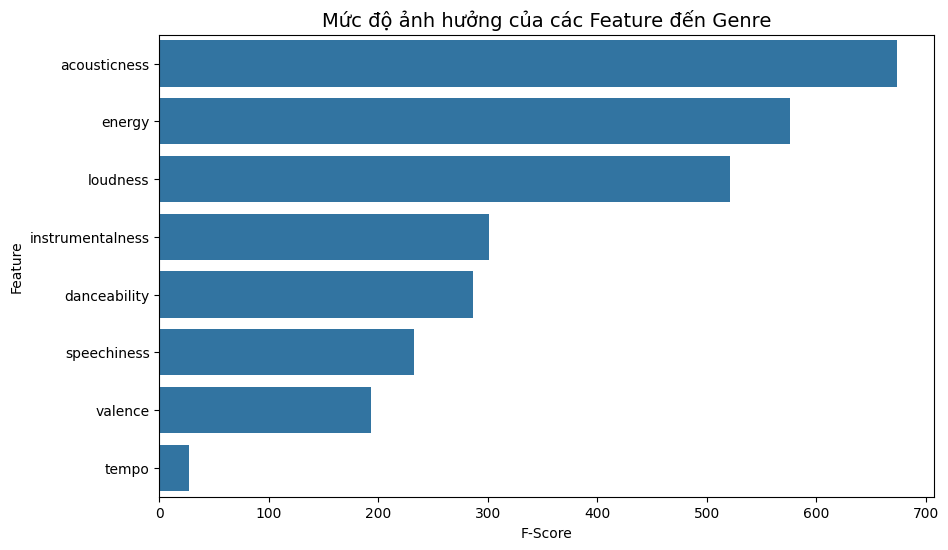

In [13]:
# dùng ANOVA
# chọn 8 cái như ma trận tương quan tui co giải thích phía dưới
from sklearn.feature_selection import f_classif

# Chọn feature
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]

anova_df = df[features + ['Class']].dropna()

X = anova_df[features]
y = anova_df['Class']

# Tính ANOVA F-score
f_scores, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    'Feature': features,
    'F_score': f_scores
})
feature_scores = feature_scores.sort_values(
    by='F_score',
    ascending=False
)

print(feature_scores)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_scores,
    x='F_score',
    y='Feature'
)

plt.title(
    "Mức độ ảnh hưởng của các Feature đến Genre",
    fontsize=14
)

plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.show()

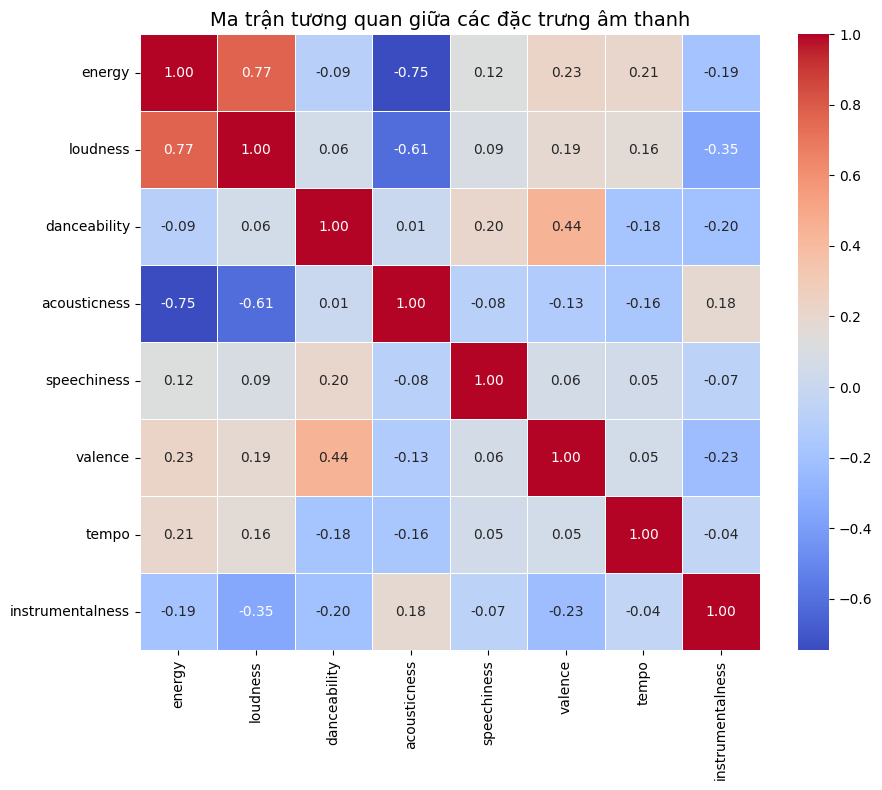

In [14]:
# MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)

# Chọn các feature cần phân tích
features = [
    'energy',
    'loudness',
    'danceability',
    'acousticness',
    'speechiness',
    'valence',
    'tempo',
    'instrumentalness'
]

# Tính ma trận tương quan
corr_matrix = df[features].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,     
    cmap='coolwarm', 
    fmt='.2f',       
    linewidths=0.5
)
plt.title("Ma trận tương quan giữa các đặc trưng âm thanh", fontsize=14)

plt.show()

# # Chọn các feature này vì đây là những đặc trưng âm thanh
# # nó phản ánh phong cách và tính chất của bài hát,
# # đồng thời có khả năng phân biệt tốt giữa các thể loại nhạc.

# features = [
#     'energy',              # mức độ sôi động/năng lượng
#     'loudness',            # độ lớn âm thanh
#     'danceability',        # độ phù hợp để nhảy
#     'acousticness',        # mức độ acoustic/mộc
#     'speechiness',         # mức độ giống lời nói (rap)
#     'valence',             # độ vui vẻ/tích cực
#     'tempo',               # tốc độ bài hát
#     'instrumentalness'     # mức độ không lời
# ]

# # Không chọn một số cột khác như:
# # - artist_name, track_name:
# #   là dữ liệu text, không phù hợp để tính correlation.
# #
# # - key, mode, time_signature:
# #   là dữ liệu mang tính phân loại/categorical,
# #   ít biến thiên và khó thể hiện mối tương quan tuyến tính rõ ràng.
# #
# # - liveness:
# #   có ảnh hưởng nhưng thường không mạnh bằng các feature trên
# #   trong việc phân biệt genre.
# #
# # - popularity:
# #   phản ánh độ nổi tiếng của bài hát hơn là đặc trưng âm thanh. nó khong ảnh hyn


# ý nghĩa của việc xài Ma trận tương quan:
# Xem mức độ liên hệ giữa các đặc trưng âm thanh trong dataset.

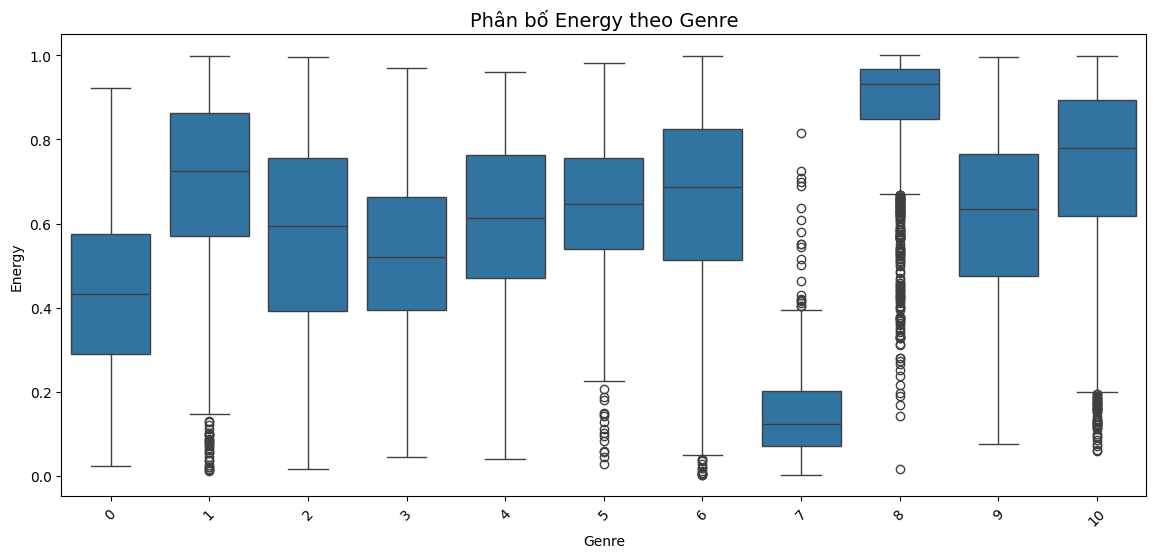

In [15]:
# BOXPLOT THEO GENRE

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='Class',
    y='energy'
)

plt.title(
    "Phân bố Energy theo Genre",
    fontsize=14
)

plt.xlabel("Genre")
plt.ylabel("Energy")

plt.xticks(rotation=45)

plt.show()

# này dựa vô bài phân tích của Minh coi đặc trưng nào ảnh hưởng mạnh và khác biệt rõ nên là trước energy
# Mục tiêu:
# So sánh phân phối của feature giữa các genre,
# bao gồm:
# - median
# - độ phân tán
# - outlier
#
# Boxplot giúp quan sát genre nào có:
# - giá trị cao/thấp hơn
# - dữ liệu ổn định hay biến động mạnh
#
# Ở đây chọn feature "energy"
# vì đây là đặc trưng quan trọng trong âm nhạc
# và có sự khác biệt rõ giữa các genre.

       danceability    energy  speechiness  acousticness   valence
Class                                                             
0          0.530466  0.439463     0.043989      0.580676  0.388546
1          0.538002  0.688784     0.067952      0.189024  0.506410
2          0.561626  0.573651     0.060550      0.389249  0.610081
3          0.497497  0.526979     0.078138      0.728095  0.629100
4          0.593961  0.602628     0.042307      0.313610  0.619455
5          0.724016  0.643204     0.240016      0.204467  0.548072
6          0.550992  0.652035     0.067541      0.230709  0.490466
7          0.427356  0.156317     0.044861      0.908020  0.226846
8          0.411686  0.876008     0.088433      0.027171  0.319123
9          0.633129  0.617447     0.074140      0.295091  0.517811
10         0.500887  0.734699     0.060319      0.140883  0.496021


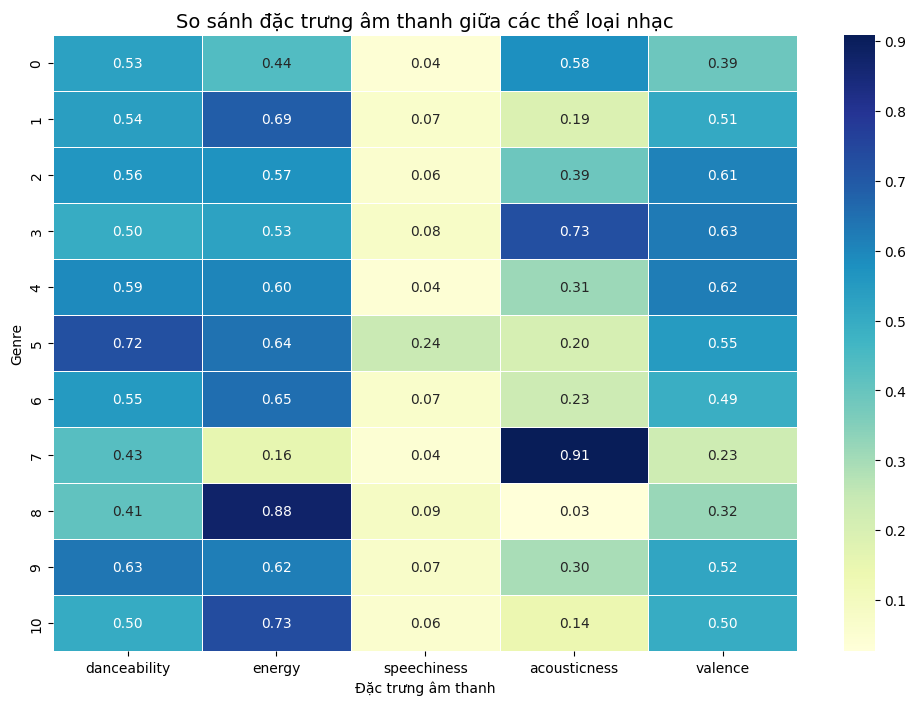

In [16]:
# SO SÁNH NHIỀU FEATURE GIỮA CÁC GENRE

# Chọn các feature cần phân tích

features = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'valence'
]
genre_features = df.groupby('Class')[features].mean()

print(genre_features)

# VẼ HEATMAP
plt.figure(figsize=(12, 8))

sns.heatmap(
    genre_features,
    annot=True,      # hiện giá trị
    cmap='YlGnBu',   # màu sắc
    fmt='.2f',
    linewidths=0.5
)
plt.title("So sánh đặc trưng âm thanh giữa các thể loại nhạc", fontsize=14)

plt.xlabel("Đặc trưng âm thanh")
plt.ylabel("Genre")

plt.show()

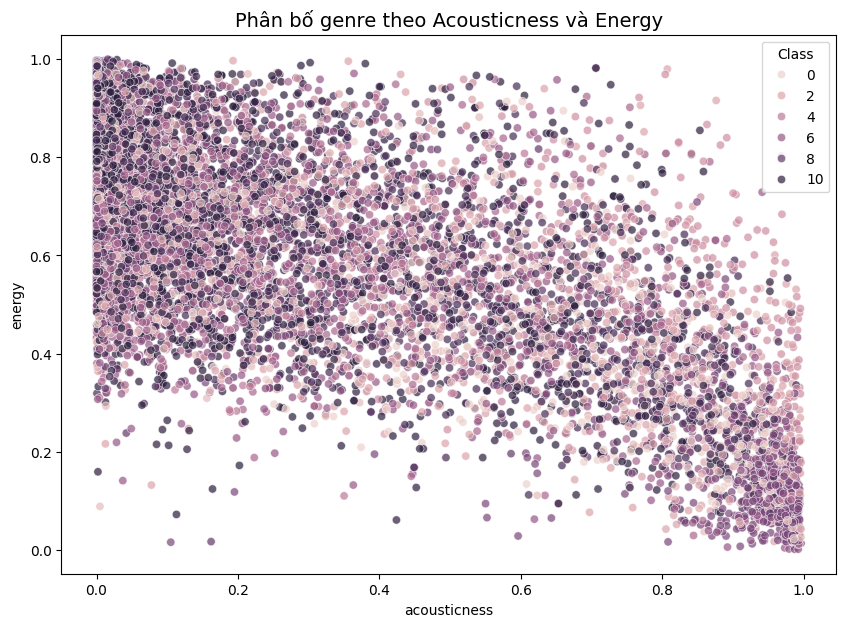

In [17]:
# SCATTER PLOT:
# XEM GENRE NÀO TÁCH BIỆT / OVERLAP

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='acousticness',
    y='energy',
    hue='Class',
    alpha=0.7
)

# Tiêu đề
plt.title("Phân bố genre theo Acousticness và Energy", fontsize=14)

# Hiển thị
plt.show()

In [18]:
# Chọn acousticness và energy vì đây là hai feature
# có khả năng phân biệt các genre rất rõ ràng.
#
# - energy:
#   phản ánh mức độ mạnh, sôi động của bài hát.
#
# - acousticness:
#   phản ánh mức độ mộc/acoustic của bài hát.
#
# Hai feature này có tính chất gần như đối lập:
#
# - Metal/Rock:
#   thường energy cao và acousticness thấp.
#
# - Acoustic/Folk:
#   thường acousticness cao và energy thấp.
#
# Vì vậy khi vẽ scatter plot,
# các genre sẽ dễ tách thành các vùng khác nhau,
# giúp quan sát:
#
# - genre nào tách biệt tốt
# - genre nào bị overlap
#
# Ngoài ra, ở correlation matrix trước đó,
# energy và acousticness cũng có tương quan âm mạnh,
# cho thấy chúng mang nhiều thông tin quan trọng
# về phong cách âm thanh của bài hát.

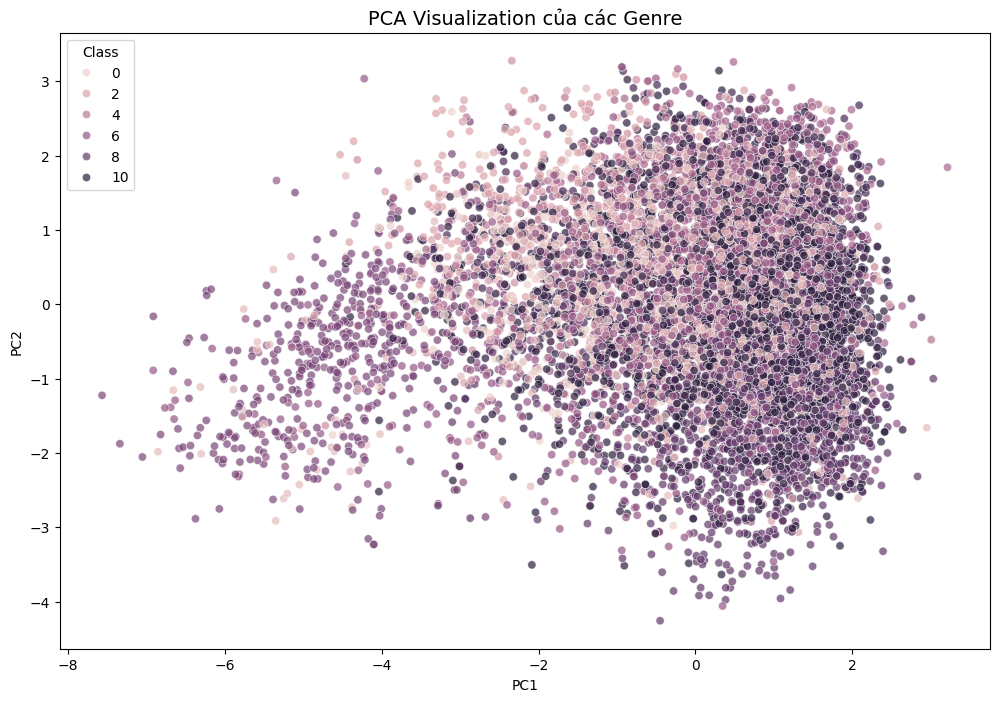

In [19]:
# PCA VISUALIZATION

# Chọn feature
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]

pca_data = df[features + ['Class']]
pca_data = pca_data.dropna()

X = pca_data[features]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)
pca_df['Class'] = pca_data['Class'].values
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Class',
    alpha=0.7
)

plt.title("PCA Visualization của các Genre", fontsize=14)

plt.show()

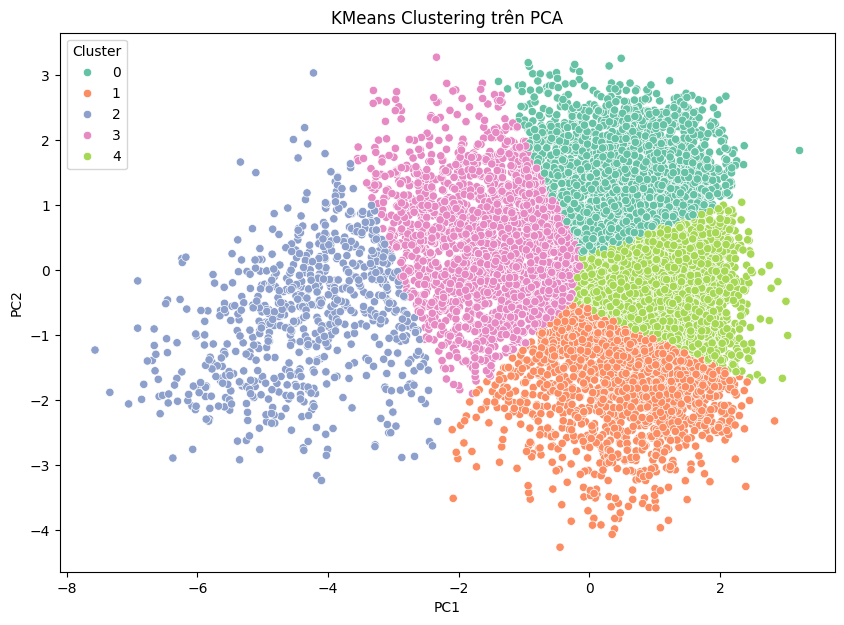

In [20]:
#  dùng pca để giảm chiều dữ liệu rồi dùng kmeans để tính, 
# kmean sẽ cho mình thấy dữ liệu tự nhiên có tạo thành nhóm giống genre không
from sklearn.cluster import KMeans

# Dùng dữ liệu PCA
kmeans = KMeans(n_clusters=5, random_state=42)

pca_df['Cluster'] = kmeans.fit_predict(X_pca)

# Vẽ cluster
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)

plt.title("KMeans Clustering trên PCA")

plt.show()

# KMeans là thuật toán học không giám sát (Unsupervised Learning),
# nghĩa là mô hình KHÔNG sử dụng nhãn genre thật mà là dữ liệu tự nhiên,
# chỉ dựa vào độ giống nhau giữa các feature âm thanh
# như energy, danceability, acousticness,...
#
# Nếu các cluster tạo ra gần giống với genre thật,( cluster là 1 nhóm dữ liệu giống nnhau)
# 
# - Mỗi genre có đặc trưng âm thanh riêng
# - Dữ liệu có cấu trúc phân nhóm rõ ràng
# - Các feature âm thanh có khả năng phân loại genre tốt

In [21]:
# Cấu trúc lưu ảnh hoặc file csv hoặc dữ liệu nào cần thiết
# Đây là cấu trúc lưu file csv, nhưng hầu như công đoạn này lưu ảnh/file csv

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_multivariateAnalysis.csv"
filepath = os.path.join("..", "Notebooks", "EDA", "MultivariateAnalysis", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: ..\Notebooks\EDA\MultivariateAnalysis\20260520_215925_data_multivariateAnalysis.csv
